# Traffic Volume Prediction: Data Modelling

This notebook loads cleaned data from `cleaned data/` (produced by `EDA_and_feature_engineering.ipynb`)
and fits regression models to predict traffic volume using direct weather measurements and ERA5 climate data.

Models used: Linear Regression, Decision Tree, Random Forest, Bagging, XGBoost.

# 1. Import Modules

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, BaggingRegressor
from xgboost import XGBRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 2. Load Cleaned Data

In [2]:
traffic = pd.read_csv('cleaned data/traffic.csv', parse_dates=['date_time'])
ERA5 = pd.read_csv('cleaned data/ERA5.csv', parse_dates=['date_time'])

dummy_holiday = pd.read_csv('cleaned data/dummy_holiday.csv')
dummy_weaMain = pd.read_csv('cleaned data/dummy_weaMain.csv')
dummy_weaDesc = pd.read_csv('cleaned data/dummy_weaDesc.csv')
dummy_dayOfWeek = pd.read_csv('cleaned data/dummy_dayOfWeek.csv')
dummy_hour = pd.read_csv('cleaned data/dummy_hour.csv')
dummy_month = pd.read_csv('cleaned data/dummy_month.csv')

print('Loaded successfully.')
traffic.head()

Loaded successfully.


,date_time,year,month,day,hour,day_of_week,holiday,traffic_volume,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description
0,2012-10-02 09:00:00,2012,10,2,9,Tuesday,NaN,5545,288.28,0.0,0.0,40,Clouds,scattered clouds
1,2012-10-02 10:00:00,2012,10,2,10,Tuesday,NaN,4516,289.36,0.0,0.0,75,Clouds,broken clouds
2,2012-10-02 11:00:00,2012,10,2,11,Tuesday,NaN,4767,289.58,0.0,0.0,90,Clouds,overcast clouds
3,2012-10-02 12:00:00,2012,10,2,12,Tuesday,NaN,5026,290.13,0.0,0.0,90,Clouds,overcast clouds
4,2012-10-02 13:00:00,2012,10,2,13,Tuesday,NaN,4918,291.14,0.0,0.0,75,Clouds,broken clouds


# 3. Shared Setup

"Bad weather" is defined as any row where `weather_main` is not 'Clear' or 'Clouds'.

In [3]:
# Array for "bad weather" (NOT "Clear" AND NOT "Clouds") booleans in array
bad_weather = (traffic.weather_main != 'Clear') & (traffic.weather_main != 'Clouds')

bad_weather.head()

0    False
1    False
2    False
3    False
4    False
Name: weather_main, dtype: bool

## Model List

The same five regression models are applied across all feature sets.

In [4]:
# List of models
models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(),
    'Random Forest' : RandomForestRegressor(),
    'Bagging': BaggingRegressor(),
    'xGBoost': XGBRegressor(),
}

# 4. Modelling on Traffic Weather Data

From the EDA, we fit:
- Qualitative: Hour of day (24), Day of the week (7), Holidays (11), and Weather description (11 or 38)
- Quantitative: Temperature

Rainfall, Snowfall, and Cloud coverage are not used due to redundancy with weather descriptions.

The test set is the last 30% of rows (chronological split), to simulate future traffic prediction rather than interpolation.

"Bad weather RMSE" is RMSE computed only on rows where `bad_weather` is True.

## 4.1 Build Feature Sets

In [5]:
# Dataframe for no weather conditions considered in model
X_none = pd.concat([traffic.temp, dummy_hour, dummy_dayOfWeek, dummy_holiday],
                   axis=1)
y_none = traffic.traffic_volume

X_none.head()

,temp,hr0,hr1,hr2,hr3,hr4,hr5,hr6,hr7,hr8,...,Columbus Day,Independence Day,Labor Day,Martin Luther King Jr Day,Memorial Day,New Years Day,State Fair,Thanksgiving Day,Veterans Day,Washingtons Birthday
0,288.28,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,289.36,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,289.58,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,290.13,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,291.14,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [6]:
# Dataframe for main weather conditions considered in model
X_main = pd.concat([traffic.temp, dummy_hour, dummy_dayOfWeek, dummy_holiday, dummy_weaMain],
                   axis=1)
y_main = traffic.traffic_volume

X_main.head()

,temp,hr0,hr1,hr2,hr3,hr4,hr5,hr6,hr7,hr8,...,Clouds,Drizzle,Fog,Haze,Mist,Rain,Smoke,Snow,Squall,Thunderstorm
0,288.28,False,False,False,False,False,False,False,False,False,...,True,False,False,False,False,False,False,False,False,False
1,289.36,False,False,False,False,False,False,False,False,False,...,True,False,False,False,False,False,False,False,False,False
2,289.58,False,False,False,False,False,False,False,False,False,...,True,False,False,False,False,False,False,False,False,False
3,290.13,False,False,False,False,False,False,False,False,False,...,True,False,False,False,False,False,False,False,False,False
4,291.14,False,False,False,False,False,False,False,False,False,...,True,False,False,False,False,False,False,False,False,False


In [7]:
# Dataframe for detailed weather descriptions considered in model
X_desc = pd.concat([traffic.temp, dummy_hour, dummy_dayOfWeek, dummy_holiday, dummy_weaDesc],
                   axis=1)
y_desc = traffic.traffic_volume

X_desc.head()

,temp,hr0,hr1,hr2,hr3,hr4,hr5,hr6,hr7,hr8,...,sleet,smoke,snow,thunderstorm,thunderstorm with drizzle,thunderstorm with heavy rain,thunderstorm with light drizzle,thunderstorm with light rain,thunderstorm with rain,very heavy rain
0,288.28,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,289.36,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,289.58,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,290.13,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,291.14,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


## 4.2 Apply Models (No Weather)

In [8]:
# Empty lists 
model_used = []
r2 = []
RMSE_train = []
RMSE_test = []
RMSE_bad_weather = []

# Split into training and test data
rows = int(len(X_none.index) * 3/10)

X_train = X_none[:-rows]
X_test = X_none[-rows:]

y_train = y_none[:-rows]
y_test = y_none[-rows:]

bad_weather_test = bad_weather[-rows:]

# Evaluate models
for name, model in models.items():
    # Training
    model.fit(X_train, y_train)
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Results
    model_r2 = r2_score(y_test, y_test_pred)
    model_rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
    model_rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))

    # Results (Bad weather)
    y_bad_weather = y_test[bad_weather_test]
    y_bad_weather_pred = y_test_pred[bad_weather_test]
    model_rmse_bad_weather = np.sqrt(mean_squared_error(y_bad_weather, y_bad_weather_pred))
    
    # Append to lists
    model_used.append(name)
    r2.append(model_r2)
    RMSE_train.append(model_rmse_train)
    RMSE_test.append(model_rmse_test)
    RMSE_bad_weather.append(model_rmse_bad_weather)

    # Results report
    print(f'--------- Results for model: {name} ---------')
    print(f'Test R2 score: {model_r2}')
    print(f'Train RMSE: {model_rmse_train}')
    print(f'Test RMSE: {model_rmse_test}')
    print(f'Bad Weather RMSE: {model_rmse_bad_weather}')
    print()

--------- Results for model: Linear Regression ---------
Test R2 score: 0.832301932398759
Train RMSE: 823.1043747687768
Test RMSE: 808.8207887635139
Bad Weather RMSE: 857.5569461935241

--------- Results for model: Decision Tree ---------
Test R2 score: 0.8821506603675381
Train RMSE: 77.94922969253
Test RMSE: 678.0345942747925
Bad Weather RMSE: 714.2434921836725

--------- Results for model: Random Forest ---------
Test R2 score: 0.9173147558302482
Train RMSE: 200.91093395013678
Test RMSE: 567.9397719179551
Bad Weather RMSE: 600.4666780997918

--------- Results for model: Bagging ---------
Test R2 score: 0.913811193758768
Train RMSE: 224.81282615104791
Test RMSE: 579.8473929477648
Bad Weather RMSE: 610.68690009808

--------- Results for model: xGBoost ---------
Test R2 score: 0.9362441653874394
Train RMSE: 440.4728133228215
Test RMSE: 498.7101919008958
Bad Weather RMSE: 543.9349740463786



In [9]:
# Create dataframe for this result and save to csv
no_weather_results = {
    'model': model_used,
    'r2': r2,
    'train_rmse': RMSE_train,
    'test_rmse': RMSE_test,
    'bad_weather_rmse': RMSE_bad_weather
}

no_weather_results = pd.DataFrame(no_weather_results)
no_weather_results.to_csv(r'Results/results_weather_none.csv', index=False)

print(no_weather_results)

               model        r2  train_rmse   test_rmse  bad_weather_rmse
0  Linear Regression  0.832302  823.104375  808.820789        857.556946
1      Decision Tree  0.882151   77.949230  678.034594        714.243492
2      Random Forest  0.917315  200.910934  567.939772        600.466678
3            Bagging  0.913811  224.812826  579.847393        610.686900
4            xGBoost  0.936244  440.472813  498.710192        543.934974


## 4.3 Apply Models (weather_main)

In [10]:
# Empty lists 
model_used = []
r2 = []
RMSE_train = []
RMSE_test = []
RMSE_bad_weather = []

# Split into training and test data
rows = int(len(X_main.index) * 3/10)

X_train = X_main[:-rows]
X_test = X_main[-rows:]

y_train = y_main[:-rows]
y_test = y_main[-rows:]

bad_weather_test = bad_weather[-rows:]

# Evaluate models
for name, model in models.items():
    # Training
    model.fit(X_train, y_train)
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Results
    model_r2 = r2_score(y_test, y_test_pred)
    model_rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
    model_rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))

    # Results (Bad weather)
    y_bad_weather = y_test[bad_weather_test]
    y_bad_weather_pred = y_test_pred[bad_weather_test]
    model_rmse_bad_weather = np.sqrt(mean_squared_error(y_bad_weather, y_bad_weather_pred))
    
    # Append to lists
    model_used.append(name)
    r2.append(model_r2)
    RMSE_train.append(model_rmse_train)
    RMSE_test.append(model_rmse_test)
    RMSE_bad_weather.append(model_rmse_bad_weather)

    # Results report
    print(f'--------- Results for model: {name} ---------')
    print(f'Test R2 score: {model_r2}')
    print(f'Train RMSE: {model_rmse_train}')
    print(f'Test RMSE: {model_rmse_test}')
    print(f'Bad Weather RMSE: {model_rmse_bad_weather}')
    print()

--------- Results for model: Linear Regression ---------
Test R2 score: 0.833687975362988
Train RMSE: 821.0703829142789
Test RMSE: 805.4713571811429
Bad Weather RMSE: 853.7790127064674

--------- Results for model: Decision Tree ---------
Test R2 score: 0.8808461264038282
Train RMSE: 38.56221459789601
Test RMSE: 681.7770200575093
Bad Weather RMSE: 738.3905092654078

--------- Results for model: Random Forest ---------
Test R2 score: 0.9268792400315325
Train RMSE: 195.59743819077056
Test RMSE: 534.0828399683692
Bad Weather RMSE: 574.6955239870642

--------- Results for model: Bagging ---------
Test R2 score: 0.9239376591016127
Train RMSE: 225.15556843725503
Test RMSE: 544.7197472639683
Bad Weather RMSE: 585.8392888724368

--------- Results for model: xGBoost ---------
Test R2 score: 0.9395730544182934
Train RMSE: 428.38803835693597
Test RMSE: 485.5160567885917
Bad Weather RMSE: 532.327224363458



In [11]:
# Create dataframe for this result and save to csv
weather_main_results = {
    'model': model_used,
    'r2': r2,
    'train_rmse': RMSE_train,
    'test_rmse': RMSE_test,
    'bad_weather_rmse': RMSE_bad_weather
}

weather_main_results = pd.DataFrame(weather_main_results)
weather_main_results.to_csv(r'Results/results_weather_main.csv', index=False)

print(weather_main_results)

               model        r2  train_rmse   test_rmse  bad_weather_rmse
0  Linear Regression  0.833688  821.070383  805.471357        853.779013
1      Decision Tree  0.880846   38.562215  681.777020        738.390509
2      Random Forest  0.926879  195.597438  534.082840        574.695524
3            Bagging  0.923938  225.155568  544.719747        585.839289
4            xGBoost  0.939573  428.388038  485.516057        532.327224


## 4.4 Apply Models (weather_description)

In [12]:
# Empty lists 
model_used = []
r2 = []
RMSE_train = []
RMSE_test = []
RMSE_bad_weather = []

# Split into training and test data
rows = int(len(X_desc.index) * 3/10)

X_train = X_desc[:-rows]
X_test = X_desc[-rows:]

y_train = y_desc[:-rows]
y_test = y_desc[-rows:]

bad_weather_test = bad_weather[-rows:]

# Evaluate models
for name, model in models.items():
    # Training
    model.fit(X_train, y_train)
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Results
    model_r2 = r2_score(y_test, y_test_pred)
    model_rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
    model_rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))

    # Results (Bad weather)
    y_bad_weather = y_test[bad_weather_test]
    y_bad_weather_pred = y_test_pred[bad_weather_test]
    model_rmse_bad_weather = np.sqrt(mean_squared_error(y_bad_weather, y_bad_weather_pred))
    
    # Append to lists
    model_used.append(name)
    r2.append(model_r2)
    RMSE_train.append(model_rmse_train)
    RMSE_test.append(model_rmse_test)
    RMSE_bad_weather.append(model_rmse_bad_weather)

    # Results report
    print(f'--------- Results for model: {name} ---------')
    print(f'Test R2 score: {model_r2}')
    print(f'Train RMSE: {model_rmse_train}')
    print(f'Test RMSE: {model_rmse_test}')
    print(f'Bad Weather RMSE: {model_rmse_bad_weather}')
    print()

--------- Results for model: Linear Regression ---------
Test R2 score: 0.8333333666912951
Train RMSE: 819.8443251301878
Test RMSE: 806.3296085253361
Bad Weather RMSE: 854.8780033999396

--------- Results for model: Decision Tree ---------
Test R2 score: 0.8829209604447685
Train RMSE: 26.564765500589175
Test RMSE: 675.8150385036165
Bad Weather RMSE: 706.5618527293159

--------- Results for model: Random Forest ---------
Test R2 score: 0.9271662138881348
Train RMSE: 194.48694294857367
Test RMSE: 533.0337638298449
Bad Weather RMSE: 570.6462023092624

--------- Results for model: Bagging ---------
Test R2 score: 0.9229811646207744
Train RMSE: 226.66894206356304
Test RMSE: 548.1340102567566
Bad Weather RMSE: 587.3544460844814

--------- Results for model: xGBoost ---------
Test R2 score: 0.9408150389075106
Train RMSE: 434.80651851142625
Test RMSE: 480.5006276713736
Bad Weather RMSE: 520.7186526603849



In [13]:
# Create dataframe for this result and save to csv
weather_desc_results = {
    'model': model_used,
    'r2': r2,
    'train_rmse': RMSE_train,
    'test_rmse': RMSE_test,
    'bad_weather_rmse': RMSE_bad_weather
}

weather_desc_results = pd.DataFrame(weather_desc_results)
weather_desc_results.to_csv(r'Results/results_weather_desc.csv', index=False)

print(weather_desc_results)

               model        r2  train_rmse   test_rmse  bad_weather_rmse
0  Linear Regression  0.833333  819.844325  806.329609        854.878003
1      Decision Tree  0.882921   26.564766  675.815039        706.561853
2      Random Forest  0.927166  194.486943  533.033764        570.646202
3            Bagging  0.922981  226.668942  548.134010        587.354446
4            xGBoost  0.940815  434.806519  480.500628        520.718653


# 5. Modelling on ERA5 Climate Data

Features used:
- Qualitative: Hour of day (traffic), Day of the week (traffic), Holidays (traffic),
  and Precipitation type (ERA5, separated by a 0.1 mm threshold)
- Quantitative: Temperature (ERA5)

The 0.1 mm threshold separates lighter and heavier precipitation with reasonable proportions (see EDA). It is a hyperparameter.

Bad weather conditions follow the same definition as in the traffic dataframe, for consistency.

## 5.1 One-Hot Encoding for ERA5 Precipitation Type (with Threshold)

In [15]:
# Create temporary dataframe that includes precipitation threshold
threshold = 0.1

dummy_weaERA5 = ERA5[['ptype', 'tp']]

dummy_weaERA5.ptype = dummy_weaERA5.apply(
    lambda row: str(row.ptype) + '_light' if row['tp'] > threshold
    else str(row['ptype']) + '_heavy',
    axis=1
)

# Final one hot encoding
dummy_weaERA5 = pd.get_dummies(dummy_weaERA5.ptype)
dummy_weaERA5.head()

C:\Users\WBS\AppData\Local\Temp\ipykernel_21120\774960578.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dummy_weaERA5.ptype = dummy_weaERA5.apply(


,Freezing rain_heavy,Freezing rain_light,Ice pellets_heavy,Ice pellets_light,Rain-snow mix_heavy,Rain-snow mix_light,Rain_heavy,Rain_light,Snow_heavy,Snow_light,Wet snow_heavy,Wet snow_light,nan_heavy,nan_light
0,False,False,False,False,False,False,False,False,False,False,False,False,True,False
1,False,False,False,False,False,False,False,False,False,False,False,False,True,False
2,False,False,False,False,False,False,False,False,False,False,False,False,True,False
3,False,False,False,False,False,False,False,False,False,False,False,False,True,False
4,False,False,False,False,False,False,False,False,False,False,False,False,True,False


## 5.2 Build Feature Set

In [16]:
# Create dataframe appropriate for training
X_ERA5 = pd.concat([traffic.temp, dummy_hour, dummy_dayOfWeek, dummy_holiday, dummy_weaERA5],
                   axis=1)
y_ERA5 = traffic.traffic_volume

X_ERA5.head()

,temp,hr0,hr1,hr2,hr3,hr4,hr5,hr6,hr7,hr8,...,Rain-snow mix_heavy,Rain-snow mix_light,Rain_heavy,Rain_light,Snow_heavy,Snow_light,Wet snow_heavy,Wet snow_light,nan_heavy,nan_light
0,288.28,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
1,289.36,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
2,289.58,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
3,290.13,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
4,291.14,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False


## 5.3 Apply Models

In [17]:
# Empty lists 
model_used = []
r2 = []
RMSE_train = []
RMSE_test = []
RMSE_bad_weather = []

# Split into training and test data
rows = int(len(X_main.index) * 3/10)

X_train = X_ERA5[:-rows]
X_test = X_ERA5[-rows:]

y_train = y_ERA5[:-rows]
y_test = y_ERA5[-rows:]

bad_weather_test = bad_weather[-rows:]

# Evaluate models
for name, model in models.items():
    # Training
    model.fit(X_train, y_train)
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Results
    model_r2 = r2_score(y_test, y_test_pred)
    model_rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
    model_rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))

    # Results (Bad weather)
    y_bad_weather = y_test[bad_weather_test]
    y_bad_weather_pred = y_test_pred[bad_weather_test]
    model_rmse_bad_weather = np.sqrt(mean_squared_error(y_bad_weather, y_bad_weather_pred))
    
    # Append to lists
    model_used.append(name)
    r2.append(model_r2)
    RMSE_train.append(model_rmse_train)
    RMSE_test.append(model_rmse_test)
    RMSE_bad_weather.append(model_rmse_bad_weather)

    # Results report
    print(f'--------- Results for model: {name} ---------')
    print(f'Test R2 score: {model_r2}')
    print(f'Train RMSE: {model_rmse_train}')
    print(f'Test RMSE: {model_rmse_test}')
    print(f'Bad Weather RMSE: {model_rmse_bad_weather}')
    print()

--------- Results for model: Linear Regression ---------
Test R2 score: 0.8382728649889253
Train RMSE: 814.0926142006439
Test RMSE: 794.2911481448284
Bad Weather RMSE: 830.1632877784766

--------- Results for model: Decision Tree ---------
Test R2 score: 0.891886770548223
Train RMSE: 41.89287677730863
Test RMSE: 649.423045927954
Bad Weather RMSE: 676.0127334226821

--------- Results for model: Random Forest ---------
Test R2 score: 0.9287456657101668
Train RMSE: 184.89919851665942
Test RMSE: 527.2224798753339
Bad Weather RMSE: 545.9417778324668

--------- Results for model: Bagging ---------
Test R2 score: 0.9242749934729741
Train RMSE: 208.1267704369166
Test RMSE: 543.510496543457
Bad Weather RMSE: 568.1235653843348

--------- Results for model: xGBoost ---------
Test R2 score: 0.9443638510753567
Train RMSE: 418.52226244152416
Test RMSE: 465.87221181341744
Bad Weather RMSE: 484.99705427536435



In [18]:
# Create dataframe for this result and save to csv
weather_ERA5_results = {
    'model': model_used,
    'r2': r2,
    'train_rmse': RMSE_train,
    'test_rmse': RMSE_test,
    'bad_weather_rmse': RMSE_bad_weather
}

weather_ERA5_results = pd.DataFrame(weather_ERA5_results)
weather_ERA5_results.to_csv(r'Results/results_ERA5.csv', index=False)

print(weather_ERA5_results)

               model        r2  train_rmse   test_rmse  bad_weather_rmse
0  Linear Regression  0.838273  814.092614  794.291148        830.163288
1      Decision Tree  0.891887   41.892877  649.423046        676.012733
2      Random Forest  0.928746  184.899199  527.222480        545.941778
3            Bagging  0.924275  208.126770  543.510497        568.123565
4            xGBoost  0.944364  418.522262  465.872212        484.997054


# 6. Compare Evaluations Across Approaches

## 6.1 Load Results

In [19]:
# Read result csvs
evaluation_none = pd.read_csv(r'Results/results_weather_none.csv')
evaluation_main = pd.read_csv(r'Results/results_weather_main.csv')
evaluation_desc = pd.read_csv(r'Results/results_weather_desc.csv')
evaluation_ERA5 = pd.read_csv(r'Results/results_ERA5.csv')

evaluation_ERA5

,model,r2,train_rmse,test_rmse,bad_weather_rmse
0,Linear Regression,0.838273,814.092614,794.291148,830.163288
1,Decision Tree,0.891887,41.892877,649.423046,676.012733
2,Random Forest,0.928746,184.899199,527.222480,545.941778
3,Bagging,0.924275,208.126770,543.510497,568.123565
4,xGBoost,0.944364,418.522262,465.872212,484.997054


In [20]:
# Add a new column for each dataframe saying where the source is
evaluation_none['Approach'] = 'No weather data'
evaluation_main['Approach'] = 'Main weather data'
evaluation_desc['Approach'] = 'Descriptive weather data'
evaluation_ERA5['Approach'] = 'ERA5 weather data'

# Merge dataframes into one
evaluation = pd.concat([evaluation_none, evaluation_main, evaluation_desc, evaluation_ERA5], ignore_index=False)
evaluation.reset_index(drop=True, inplace=True)

del evaluation_none, evaluation_main, evaluation_desc, evaluation_ERA5

evaluation.head()

,model,r2,train_rmse,test_rmse,bad_weather_rmse,Approach
0,Linear Regression,0.832302,823.104375,808.820789,857.556946,No weather data
1,Decision Tree,0.882151,77.949230,678.034594,714.243492,No weather data
2,Random Forest,0.917315,200.910934,567.939772,600.466678,No weather data
3,Bagging,0.913811,224.812826,579.847393,610.686900,No weather data
4,xGBoost,0.936244,440.472813,498.710192,543.934974,No weather data


## 6.2 Bar Plots by Regression Method and Weather Data Approach

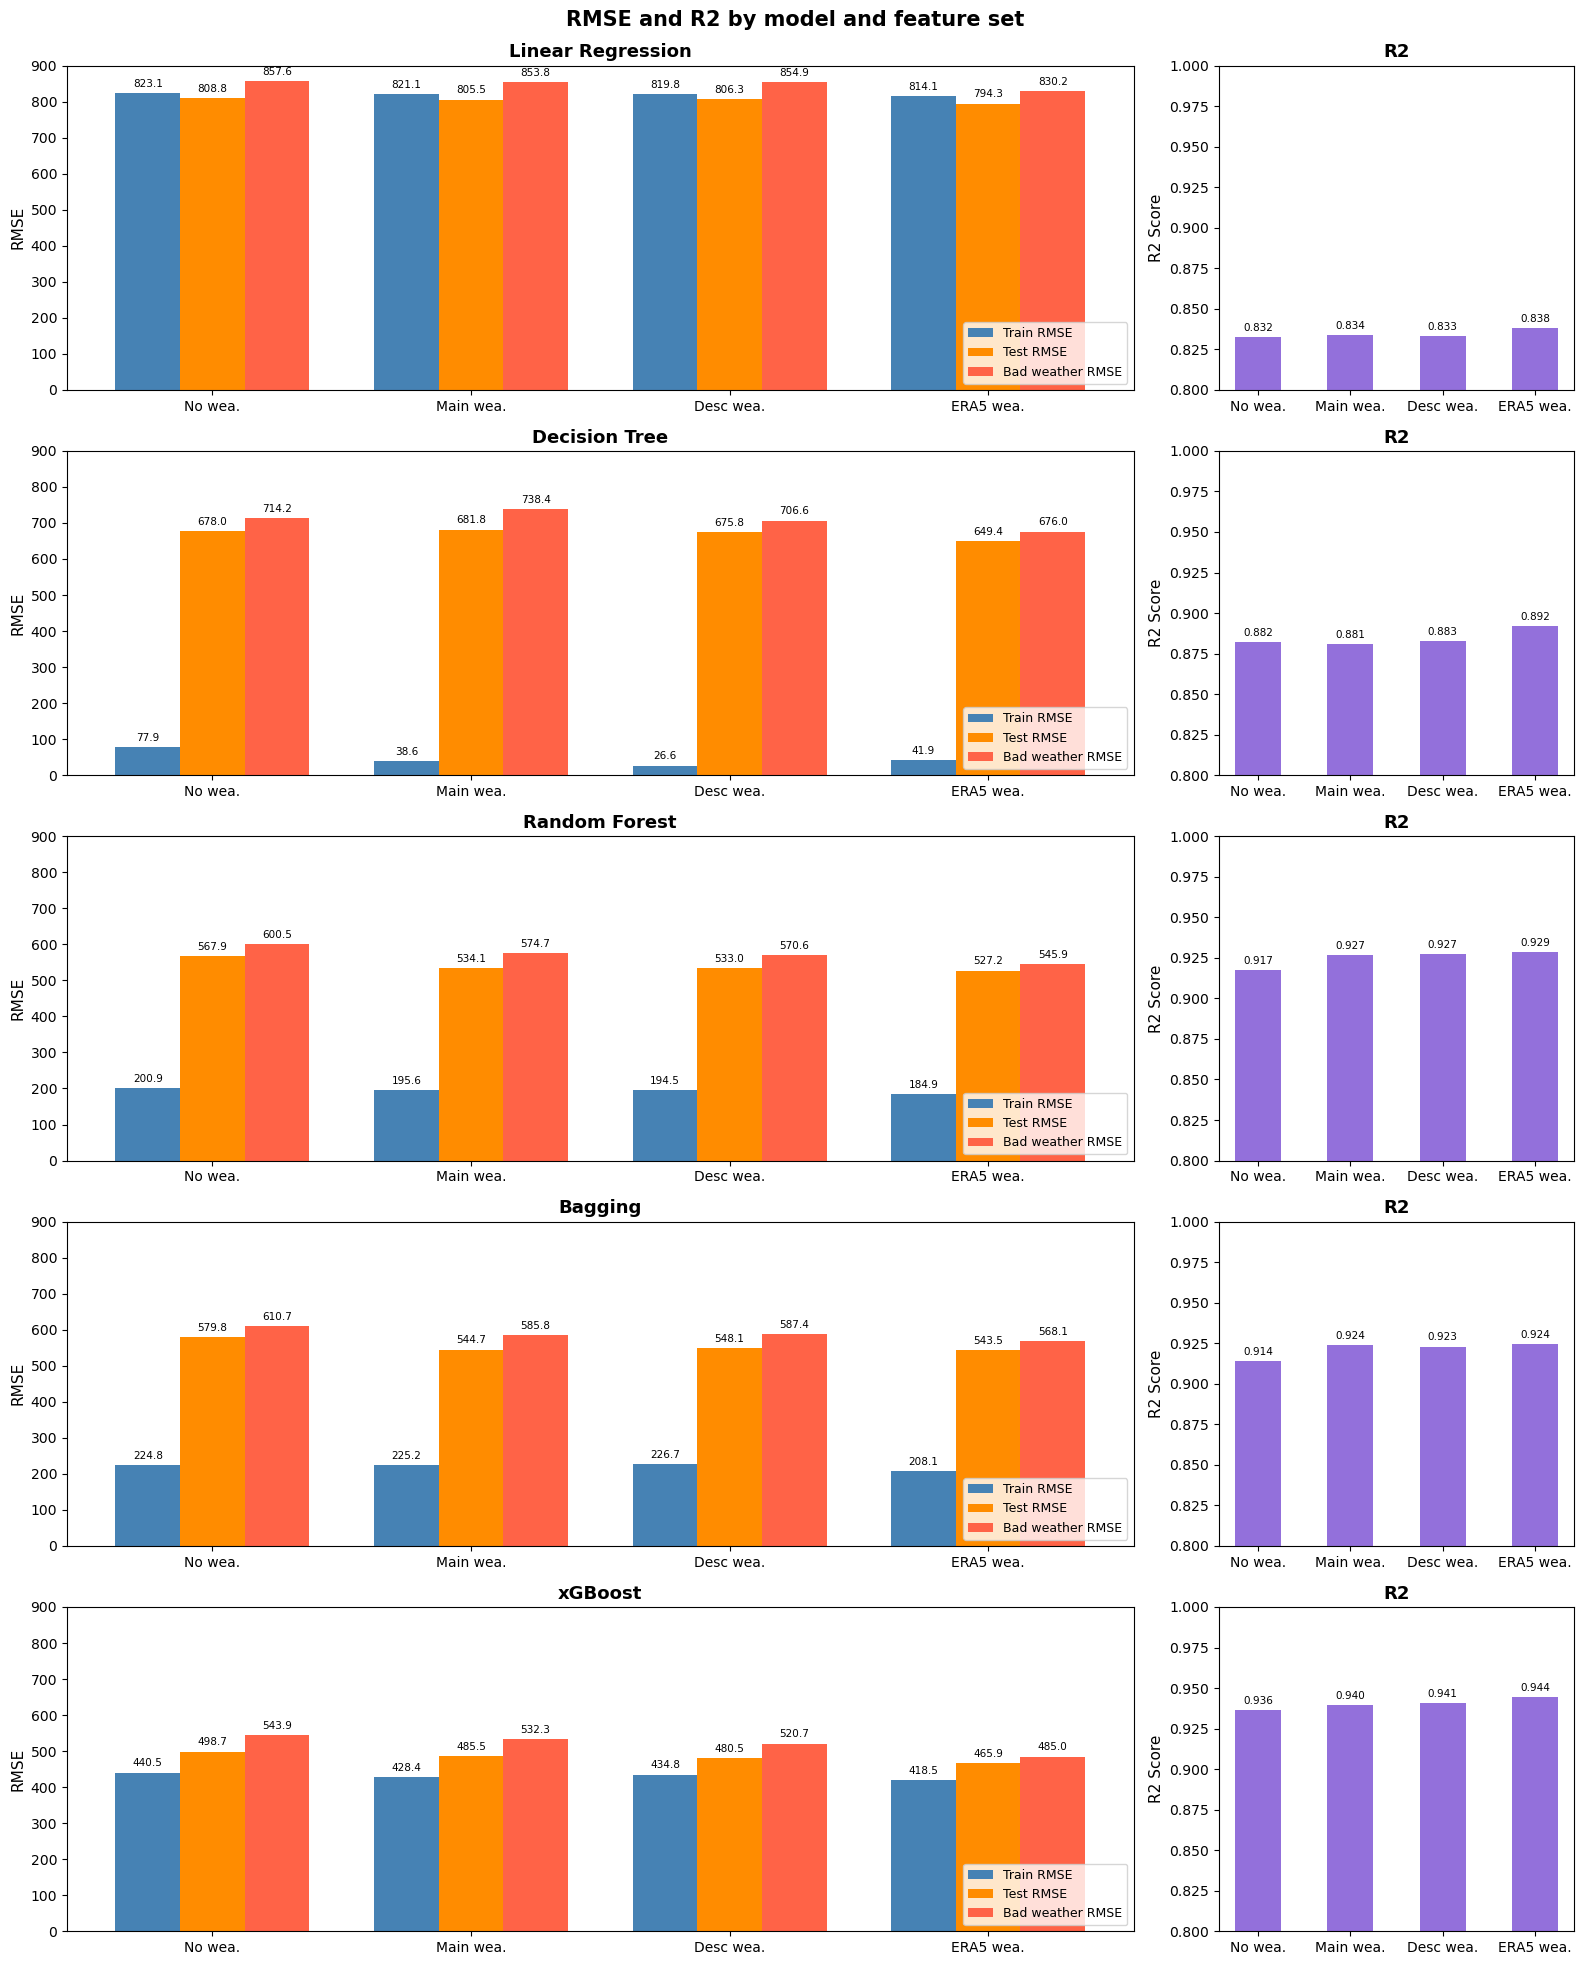

In [41]:
fig, axes = plt.subplots(5, 2, figsize=(16, 20), gridspec_kw={'width_ratios': [3, 1]})

bar_colors = ['steelblue', 'darkorange', 'tomato']
approaches = evaluation['Approach'].unique()
short_labels = ['No wea.', 'Main wea.', 'Desc wea.', 'ERA5 wea.']
model_names = list(models.keys())

x = np.arange(len(approaches))
width = 0.25

for row_idx, model_name in enumerate(model_names):
    ax_rmse = axes[row_idx, 0]
    ax_r2   = axes[row_idx, 1]

    subset = evaluation[evaluation['model'] == model_name]
    subset = subset.set_index('Approach').reindex(approaches)

    # RMSE bars
    bars = [
        ax_rmse.bar(x - width, subset['train_rmse'],       width, label='Train RMSE',       color=bar_colors[0]),
        ax_rmse.bar(x,         subset['test_rmse'],        width, label='Test RMSE',        color=bar_colors[1]),
        ax_rmse.bar(x + width, subset['bad_weather_rmse'], width, label='Bad weather RMSE', color=bar_colors[2]),
    ]
    for bar_group in bars:
        for p in bar_group:
            ax_rmse.annotate(f'{p.get_height():.1f}',
                             (p.get_x() + p.get_width() / 2., p.get_height()),
                             ha='center', va='bottom', fontsize=7.5, xytext=(0, 3),
                             textcoords='offset points')
    ax_rmse.set_title(model_name, fontsize=13, fontweight='bold')
    ax_rmse.set_xticks(x)
    ax_rmse.set_xticklabels(short_labels, fontsize=10)
    ax_rmse.set_ylabel('RMSE', fontsize=11)
    ax_rmse.set_ylim(0, 900)
    ax_rmse.legend(fontsize=9, loc='lower right')

    # R2 bars
    bar_r2 = ax_r2.bar(x, subset['r2'], width * 2, color='mediumpurple')
    for p in bar_r2:
        ax_r2.annotate(f'{p.get_height():.3f}',
                       (p.get_x() + p.get_width() / 2., p.get_height()),
                       ha='center', va='bottom', fontsize=7.5, xytext=(0, 3),
                       textcoords='offset points')
    ax_r2.set_title('R2', fontsize=13, fontweight='bold')
    ax_r2.set_xticks(x)
    ax_r2.set_xticklabels(short_labels, fontsize=10)
    ax_r2.set_ylabel('R2 Score', fontsize=11)
    ax_r2.set_ylim(0.8, 1.0)

plt.suptitle('RMSE and R2 by model and feature set\n', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('rmse_r2_by_model.png', dpi=150, bbox_inches='tight')
plt.show()

## 6.3 Real data vs Predicted data

Fitting and plotting: 100%|████████████████████████████████████████████████████████████| 20/20 [01:00<00:00,  3.05s/it]


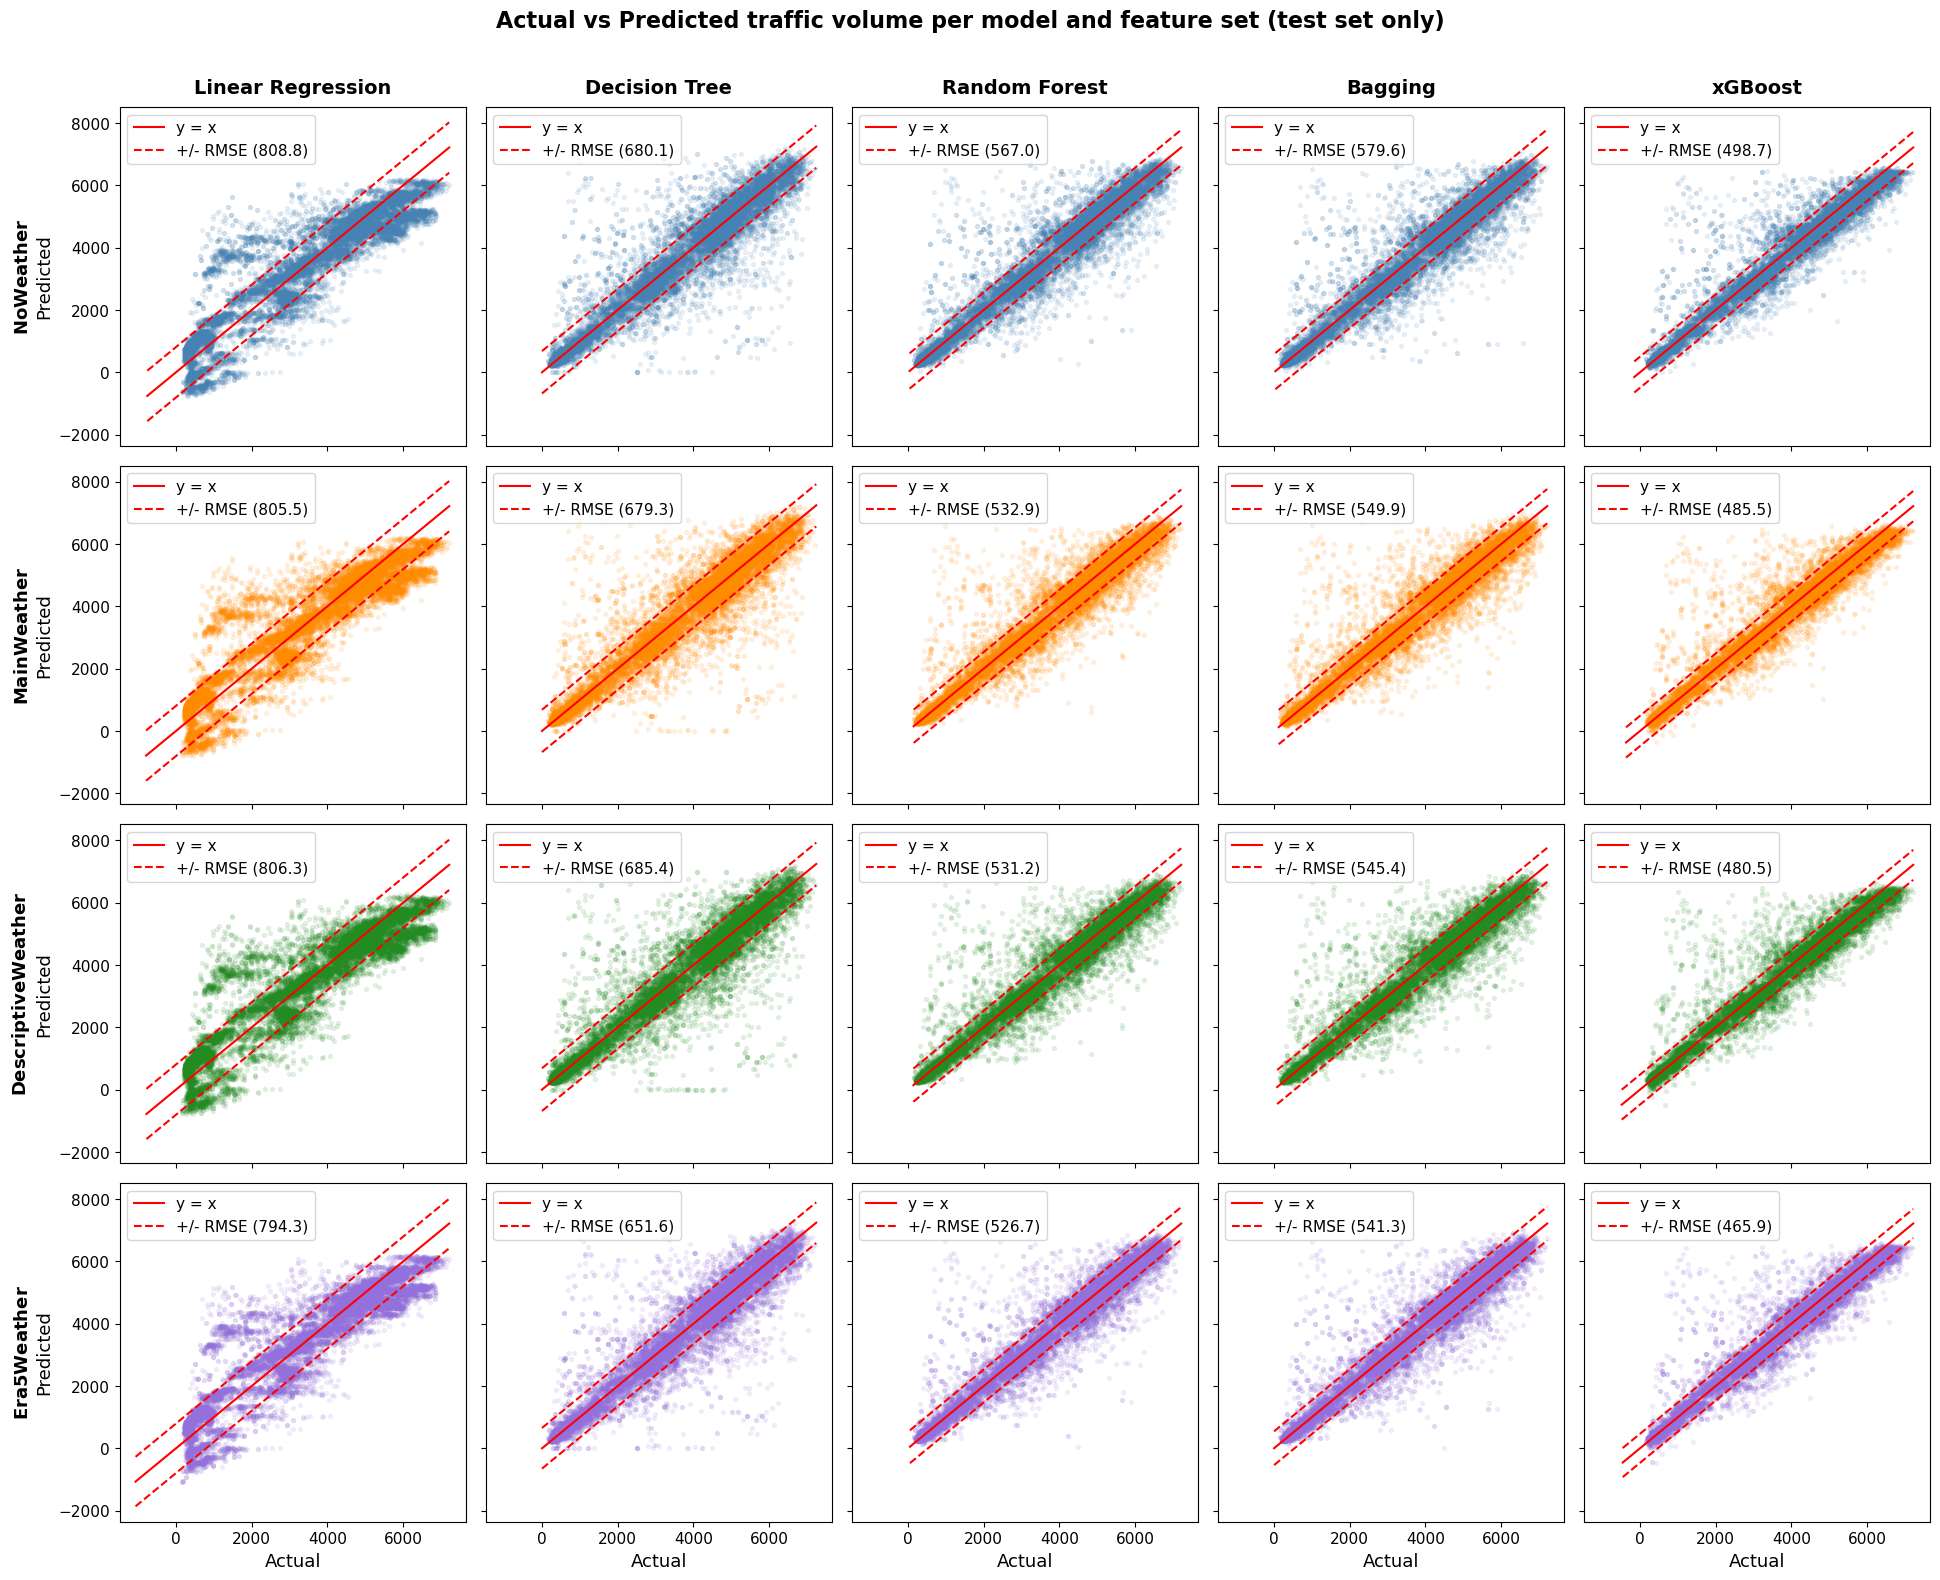

In [44]:
from sklearn.base import clone
from tqdm import tqdm

feature_sets = {
    'No weather': (X_none, y_none),
    'Main weather': (X_main, y_main),
    'Descriptive weather': (X_desc, y_desc),
    'ERA5 weather': (X_ERA5, y_ERA5),
}

colors = ['steelblue', 'darkorange', 'forestgreen', 'mediumpurple']

fig, axes = plt.subplots(4, 5, figsize=(15*1.3, 12*1.3), sharex=True, sharey=True)

total = len(feature_sets) * len(models)
with tqdm(total=total, desc='Fitting and plotting') as pbar:
    for row_idx, ((feat_name, (X, y)), color) in enumerate(zip(feature_sets.items(), colors)):
        rows = int(len(X.index) * 3/10)
        X_train = X[:-rows]
        X_test = X[-rows:]
        y_train = y[:-rows]
        y_test = y[-rows:]

        for col_idx, (model_name, model) in enumerate(models.items()):
            ax = axes[row_idx, col_idx]

            fresh_model = clone(model)
            fresh_model.fit(X_train, y_train)
            y_pred = fresh_model.predict(X_test)

            rmse = np.sqrt(mean_squared_error(y_test, y_pred))
            lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]

            ax.scatter(y_test.values, y_pred, alpha=0.1, s=8, color=color)
            ax.plot(lims, lims, color='red', linewidth=1.5, label='y = x')
            ax.plot(lims, [l + rmse for l in lims], color='red', linewidth=1.5,
                    linestyle='--', label=f'+/- RMSE ({rmse:.1f})')
            ax.plot(lims, [l - rmse for l in lims], color='red', linewidth=1.5,
                    linestyle='--')
            ax.legend(fontsize=11, loc='upper left')
            ax.tick_params(labelsize=11)

            if row_idx == 0:
                ax.set_title(model_name, fontsize=14, fontweight='bold', pad=10)
            if col_idx == 0:
                feat_name_camel = ''.join(word.capitalize() for word in feat_name.split())
                ax.set_ylabel(
                    rf'$\bf{{{feat_name_camel}}}$' + '\nPredicted',
                    fontsize=13
                )
            if row_idx == 3:
                ax.set_xlabel('Actual', fontsize=13)

            pbar.update(1)

plt.suptitle('Actual vs Predicted traffic volume per model and feature set (test set only)',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()